In [1]:
import tapas.datasets
import tapas.generators
import tapas.threat_models
import tapas.attacks
import tapas.report
from tapas.datasets.canary import create_canary
from sklearn.metrics import roc_auc_score
from utils.plotting import double_plot
from utils.my_attack import MyAttack
from utils.my_feature import MyFeature
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import random

In [2]:
def _sample_shadow_dataset(shadow_dataset_pool: list[tapas.datasets.dataset.TabularDataset], number_of_shadow_models: int):
   """_summary_

   Args:
       shadow_dataset_pool (_type_): _description_
       number_of_shadow_models (int): _description_

   Returns:
       list[tapas.datasets.dataset.TabularDataset, bool]: subset of shadow_dataset_pool of lenght number_of_shadow_models such that there is the same number of dataset with/without target.
   """
   assert number_of_shadow_models % 2 == 0, 'number_of_shadow_models should be a even integer'
   shadow_datasets = random.sample(shadow_dataset_pool[0], int(number_of_shadow_models / 2))
   shadow_datasets.extend(random.sample(shadow_dataset_pool[1], int(number_of_shadow_models / 2)))
   return shadow_datasets

# _sample_shadow_dataset(shadow_datasets, 6)

In [53]:
#ATTACK INPUT
import tapas.datasets.utils
from sklearn.linear_model import LogisticRegression
from tapas.attacks import LpDistance
from sklearn.neighbors import KernelDensity


data = tapas.datasets.TabularDataset.read("data/dummy")
ind = [int(random.random() * len(data.data))]
target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)
# data, target_record = create_canary(data)

attacker_data, defender_data = data.create_subsets(n = 2, sample_size= int(len(data) / 2))
generator = tapas.generators.Raw()

#DEFINE ATTACKER KNOLEDGE
i = int(len(defender_data) / 5)

data_knowledge = tapas.threat_models.AuxiliaryDataKnowledge(
      test_data= defender_data,
      aux_data= attacker_data,
      num_training_records= i
)

sdg_knowledge = tapas.threat_models.BlackBoxKnowledge(
    generator,
    num_synthetic_records = i,
)
print(len(data.data))

49999


In [54]:
target_record.data

,age,color,name,gender,city
22562,13.0,75.0,77.0,47.0,73.0


In [42]:
f = MyFeature()
threat_model = tapas.threat_models.TargetedMIA(
            attacker_knowledge_data=data_knowledge,
            target_record=target_record,
            attacker_knowledge_generator=sdg_knowledge,
            generate_pairs=True,
            replace_target=True
         )

test_datasets, truth_labels = threat_model._generate_samples(2, True, True)
print(truth_labels)
f(test_datasets)

[True, False]


array([[ 44.884977  ,  44.32826565,  44.5665133 ,  43.69913983,
         44.49769954,  45.        ,  45.        ,  45.        ,
         43.        ,  45.        , 677.54488133, 682.83903102,
        688.90770841, 665.82786683, 667.31140699,  90.        ,
         90.        ,  90.        ,  90.        ,  90.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ],
       [ 44.88377676,  44.32146429,  44.55471094,  43.69433887,
         44.49269854,  45.        ,  45.        ,  45.        ,
         43.        ,  45.        , 677.44378362, 682.44897117,
        688.5314636 , 665.49848966, 666.98129296,  89.        ,
         89.        ,  89.        ,  89.        ,  89.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0

In [51]:
def Fast_MIA_attack(complexity_range: list[int], run_per_range: int, number_of_tests: int):
   threat_model = tapas.threat_models.TargetedMIA(
            attacker_knowledge_data=data_knowledge,
            target_record=target_record,
            attacker_knowledge_generator=sdg_knowledge,
            generate_pairs=True,
            replace_target=True
         )
   number_of_generated_shadow_datasets = complexity_range[-1] * 2
   shadow_datasets, shadow_labels = threat_model.generate_training_samples(number_of_generated_shadow_datasets, ignore_memory=True)
   shadow_data = list(zip(shadow_datasets, shadow_labels))
   shadow_data_0 = [sd for sd in shadow_data if not sd[1]]
   shadow_data_1 = [sd for sd in shadow_data if sd[1]]
   shadow_data_pool = [shadow_data_0, shadow_data_1]
   test_datasets, truth_labels = threat_model._generate_samples(number_of_tests, False, True)
   M_0 = []
   S_0 = []
   M_1 = []
   S_1 = []
   for complexity in complexity_range:
      print('COMPLEXITY: ', complexity)
      P_0 = []
      P_1 = []
      for _ in range(run_per_range):
         sampled_shadow_data = _sample_shadow_dataset(shadow_data_pool, complexity)
         random.shuffle(sampled_shadow_data)
         sampled_datasets = [dataset[0] for dataset in sampled_shadow_data]
         sampled_labels = [dataset[1] for dataset in sampled_shadow_data]

         # attacker = tapas.attacks.ProbabilityEstimationAttack(KernelDensity(), criterion="accuracy", label="KernelEstimator")
         # attacker.train(threat_model, num_samples=complexity)

         attacker = MyAttack(n_estimators=100, features=MyFeature(), use_corr=False, use_hist=False)
         attacker.classifier.fit(sampled_datasets, sampled_labels)
         attacker.trained = True
         
         pred_labels = attacker.attack(test_datasets)
         P_0.extend([p for i, p in enumerate(pred_labels) if truth_labels[i] == False])
         P_1.extend([p for i, p in enumerate(pred_labels) if truth_labels[i] == True])
         # print('AuROC :', roc_auc_score(truth_labels, attacker.attack_score(test_datasets)))
      M_0.append(np.mean(P_0))
      S_0.append(np.std(P_0))
      M_1.append(np.mean(P_1))
      S_1.append(np.std(P_1))
   return M_0, S_0, M_1, S_1

COMPLEXITY:  10
COMPLEXITY:  50
COMPLEXITY:  100


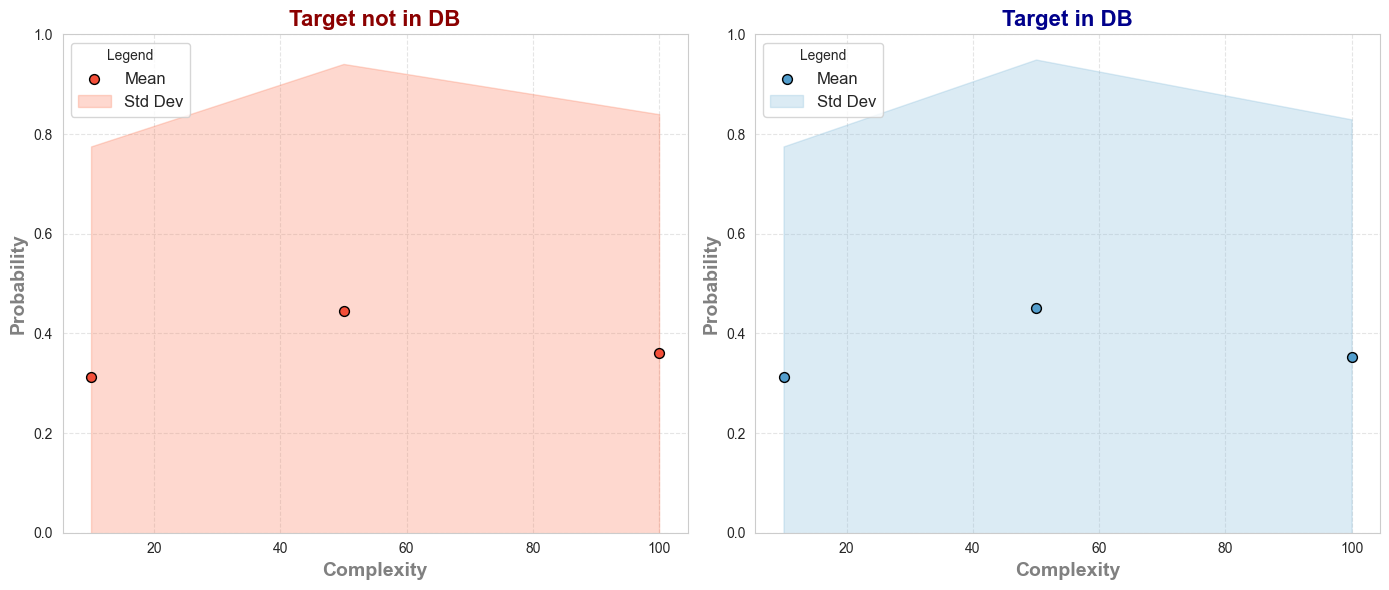

In [55]:
COMPLEXITY_RANGE = [10, 50, 100]
RUN_PER_RANGE = 5
TESTS_PER_RANGE = 100
M_0, S_0, M_1, S_1 = Fast_MIA_attack(COMPLEXITY_RANGE, RUN_PER_RANGE, TESTS_PER_RANGE)
double_plot(np.array(COMPLEXITY_RANGE), np.array(M_0), np.array(S_0), np.array(M_1), np.array(S_1))